In [1]:
import torch
import cv2
from torchvision.datasets import VOCDetection
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision import datasets

from torch import nn
import torch.nn.functional as F #For activation fns, loss fun etc.,

from torchinfo import summary #To display model architecture
from torch.utils.tensorboard  import SummaryWriter

from dataclasses import dataclass

import numpy as np
import random
import matplotlib.pyplot as plt

from tqdm import tqdm

In [2]:
import os
import time
import shutil

#### Validation dataset preparation

In [86]:
continue
val_dir = "tiny-imagenet-200/val"
img_dir = os.path.join(val_dir, "images")

with open(os.path.join(val_dir, "val_annotations.txt")) as f:
    for line in f:
        img_name, class_name, *_ = line.split("\t")

        class_dir = os.path.join(val_dir, class_name)
        os.makedirs(class_dir, exist_ok=True)

        shutil.move(
            os.path.join(img_dir, img_name),
            os.path.join(class_dir, img_name)
        )


files = os.listdir(val_dir)

for file in files:
    class_dir = os.path.join(val_dir, file)

    images = os.listdir(class_dir)

    for image in images:
        c = image.split('.')
        img_new_file_ext = c[0] + '.jpeg'
        shutil.move(
            os.path.join(class_dir, image),
            os.path.join(class_dir, img_new_file_ext)
        )

SyntaxError: 'continue' not properly in loop (2727296546.py, line 1)

In [3]:
def set_seeds():
    """
    Sets a fixed seed value for reproducibility across multiple libraries (random, NumPy)
    This ensures that model training and results remain consistent across multiple runs.
    """
    SEED_VALUE = 42

    random.seed(SEED_VALUE)

    np.random.seed(SEED_VALUE)

    torch.manual_seed(SEED_VALUE)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED_VALUE) #Single GPU
        torch.cuda.manual_seed_all(SEED_VALUE) #Multiple GPU

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = True

set_seeds()

#### Training Configuration Parameters

In [11]:
@dataclass(frozen=True)
class TrainingConfig:
    """Configuration for training"""
    batch_size: int = 128
    num_epochs: int = 5
    learning_rate: float = 1e-4

    log_interval: int = 1
    test_interval: int = 1
    data_root: int = "./tiny-imagenet-200/"
    num_workers: int = 4 #number of thread involving in loading image
    device:str = 'cpu'

train_config = TrainingConfig()
DEVICE = torch.device("cuda") if torch.cuda.is_available() else "cpu"
print(f"Available device {DEVICE}")

Available device cuda


#### Data Preprocessing

In [5]:
mean=[0.485, 0.456, 0.406]
std=[0.229, 0.224, 0.225]

preprocess = transforms.Compose([
    transforms.ToTensor()
])

common_transform = transforms.Compose([
    preprocess,
    transforms.Normalize(mean, std)
])

In [6]:
wnid_to_name = {}

with open("tiny-imagenet-200/words.txt") as f:
    for line in f:
        wnid, names = line.strip().split("\t")
        wnid_to_name[wnid] = names

print(wnid_to_name["n01443537"])

goldfish, Carassius auratus


#### Load the validation dataset

In [7]:
train_root = os.path.join(train_config.data_root, "train")
val_root = os.path.join(train_config.data_root, "val")

train_data = datasets.ImageFolder(root= train_root, transform=common_transform)
val_data = datasets.ImageFolder(root= val_root, transform=common_transform)

#### Data Loader Preparation

In [8]:
train_loader = DataLoader(
    train_data,
    shuffle=True,
    batch_size= train_config.batch_size,
    num_workers = train_config.num_workers,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

val_loader = DataLoader(
    val_data,
    shuffle=False,
    batch_size= train_config.batch_size,
    num_workers= train_config.num_workers,
    pin_memory=True,
    persistent_workers=True,
    prefetch_factor=2
)

In [10]:
print(next(iter(val_loader)))
print(next(iter(val_loader)))

[tensor([[[[ 2.1119,  2.1290,  2.1633,  ...,  2.2318,  2.2318,  2.2318],
          [ 2.1804,  2.1633,  2.1633,  ...,  2.2318,  2.2318,  2.2318],
          [ 2.2318,  2.2318,  2.1975,  ...,  2.2147,  2.2147,  2.2147],
          ...,
          [ 1.2728,  1.9578,  2.2489,  ...,  1.6838,  1.6667,  1.5982],
          [ 2.0777,  2.1119,  1.8208,  ...,  2.1462,  2.0777,  1.9920],
          [ 2.0263,  1.9578,  2.0777,  ...,  2.2318,  2.1975,  2.1975]],

         [[ 2.3936,  2.4111,  2.4111,  ...,  2.4111,  2.4111,  2.4111],
          [ 2.4286,  2.4111,  2.4111,  ...,  2.4111,  2.4111,  2.4111],
          [ 2.4286,  2.4286,  2.4111,  ...,  2.3936,  2.3936,  2.3936],
          ...,
          [ 1.4657,  2.1660,  2.4286,  ...,  1.8508,  1.8333,  1.7633],
          [ 2.4286,  2.4286,  2.1835,  ...,  2.3235,  2.3060,  2.2185],
          [ 2.4286,  2.4286,  2.4286,  ...,  2.4111,  2.4286,  2.4286]],

         [[ 2.5703,  2.5877,  2.6051,  ...,  2.6226,  2.6226,  2.6226],
          [ 2.6226,  2.6051, 

#### Display Images from the Dataset

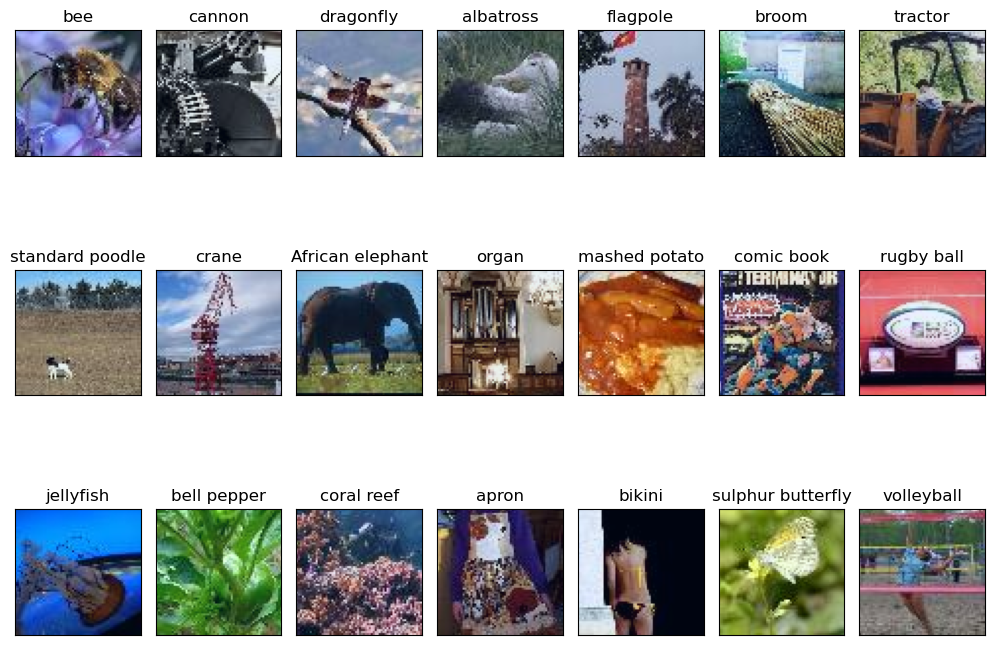

In [14]:
def visualize_images(trainloader, number_of_images=21):
    fig = plt.figure(figsize=(10,8))

    images, labels = next(iter(train_loader))

    num_rows = 3
    num_col = int(np.ceil(number_of_images/num_rows))

    for idx in range(min(number_of_images, len(images))):
        image, label = images[idx], labels[idx]

        #Create a subplot 
        ax = fig.add_subplot(num_rows, num_col, idx+1, xticks=[], yticks=[])

        image = image.squeeze()
        image = (image - image.min())/ (image.max() - image.min())
       
        ax.imshow(image.permute(1,2,0))

        names = wnid_to_name[train_data.classes[label.item()]].split(',')[0]

        ax.set_title(f"{names}")

    fig.tight_layout()
    
    plt.show()
visualize_images(train_loader)


In [16]:
 images, labels = next(iter(train_loader))

#### YOLO 20 layer pretrain

In [15]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.base_num_filters = 32
        self.filter_size = 3

        self._model = nn.Sequential(
            #-------Convolution Layer-------
            #layer   filters  size           input                 output
            #0 conv     16  3 x 3 / 1   224 x 224 x   3   ->   224 x 224 x  16
            #1 max          2 x 2 / 2   224 x 224 x  16   ->   112 x 112 x  16
            nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),

            #2 conv     32  3 x 3 / 1   112 x 112 x  16   ->   112 x 112 x  32
            #3 max          2 x 2 / 2   112 x 112 x  32   ->    56 x  56 x  32
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),

            
            #4 conv     16  1 x 1 / 1    56 x  56 x  32   ->    56 x  56 x  16
            #5 conv    128  3 x 3 / 1    56 x  56 x  16   ->    56 x  56 x 128
            #6 conv     16  1 x 1 / 1    56 x  56 x 128   ->    56 x  56 x  16
            #7 conv    128  3 x 3 / 1    56 x  56 x  16   ->    56 x  56 x 128
            #8 max          2 x 2 / 2    56 x  56 x 128   ->    28 x  28 x 128
            nn.Conv2d(in_channels=32, out_channels=16, kernel_size=1, padding=0),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=16, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=128, out_channels=16, kernel_size=1, padding=0),
            nn.BatchNorm2d(16),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=16, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),

            # 9 conv     32  1 x 1 / 1    28 x  28 x 128   ->    28 x  28 x  32
            #10 conv    256  3 x 3 / 1    28 x  28 x  32   ->    28 x  28 x 256
            #11 conv     32  1 x 1 / 1    28 x  28 x 256   ->    28 x  28 x  32
            #12 conv    256  3 x 3 / 1    28 x  28 x  32   ->    28 x  28 x 256
            #13 max          2 x 2 / 2    28 x  28 x 256   ->    14 x  14 x 256
            nn.Conv2d(in_channels=128, out_channels=32, kernel_size=1, padding=0),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=32, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=256, out_channels=32, kernel_size=1, padding=0),
            nn.BatchNorm2d(32),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=32, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(negative_slope=0.01),
            nn.MaxPool2d(kernel_size=(2,2), stride=(2,2)),

            #14 conv     64  1 x 1 / 1    14 x  14 x 256   ->    14 x  14 x  64
            #15 conv    512  3 x 3 / 1    14 x  14 x  64   ->    14 x  14 x 512
            #16 conv     64  1 x 1 / 1    14 x  14 x 512   ->    14 x  14 x  64
            #17 conv    512  3 x 3 / 1    14 x  14 x  64   ->    14 x  14 x 512
            #18 conv    128  1 x 1 / 1    14 x  14 x 512   ->    14 x  14 x 12
            #19 conv   1000  1 x 1 / 1    14 x  14 x 128   ->    14 x  14 x1000
            nn.Conv2d(in_channels=256, out_channels=64, kernel_size=1, padding=0),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=64, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=512, out_channels=64, kernel_size=1, padding=0),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=64, out_channels=512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=512, out_channels=128, kernel_size=1, padding=0),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Conv2d(in_channels=128, out_channels=200, kernel_size=1, padding=0),

            #20 avg                       14 x  14 x1000   ->  1000
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten()
        )
        
    def forward(self, x):
        return self._model(x)

In [16]:
model = Model()

model.load_state_dict(torch.load("best.pt",  map_location=DEVICE))

model = model.to(DEVICE)

#optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate)
optimizer = torch.optim.Adam(model.parameters(), lr= train_config.learning_rate, weight_decay=.0001)

logdir = "runs/80epoch-3.3M_param_dropout"

writer = SummaryWriter(logdir)

dummy_input = (1,3,64,64)

print(summary(model, dummy_input, row_settings=["var_names"], device='cpu'))

Layer (type (var_name))                  Output Shape              Param #
Model (Model)                            [1, 200]                  --
├─Sequential (_model)                    [1, 200]                  --
│    └─Conv2d (0)                        [1, 16, 64, 64]           448
│    └─BatchNorm2d (1)                   [1, 16, 64, 64]           32
│    └─LeakyReLU (2)                     [1, 16, 64, 64]           --
│    └─MaxPool2d (3)                     [1, 16, 32, 32]           --
│    └─Conv2d (4)                        [1, 32, 32, 32]           4,640
│    └─BatchNorm2d (5)                   [1, 32, 32, 32]           64
│    └─LeakyReLU (6)                     [1, 32, 32, 32]           --
│    └─MaxPool2d (7)                     [1, 32, 16, 16]           --
│    └─Conv2d (8)                        [1, 16, 16, 16]           528
│    └─BatchNorm2d (9)                   [1, 16, 16, 16]           32
│    └─LeakyReLU (10)                    [1, 16, 16, 16]           --
│    └─Con

#### Model Training and Evaluation

In [17]:
def train(model, train_loader, optimizer, DEVICE):

    #set model to training mode
    model.train()

    #Move model to specified device
    model = model.to(DEVICE)

    running_loss = 0

    correct_prediction = 0

    total_samples = 0

    for images, labels in tqdm(train_loader, desc="Training"):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        #Reset to zero
        optimizer.zero_grad()

        #Forward pass
        outputs = model(images)

        loss = F.cross_entropy(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs.data, dim=1)

        total_samples += labels.size(0)

        correct_prediction += (predicted == labels).sum().item()

    avg_loss = running_loss / len(train_loader)

    accuracy = 100 * correct_prediction/ total_samples

    return avg_loss, accuracy

In [18]:
def validation(model, val_loader, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)

            loss = F.cross_entropy(outputs, labels)

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += labels.size(0)
            
            correct_predictions += (predicted == labels).sum().item()
            
        avg_loss = running_loss / len(val_loader)

        accuracy = 100 * correct_predictions/ total_samples

    return avg_loss, accuracy 

In [19]:


def main(model, trainloader, val_loader, DEVICE='cuda'):
    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    best_val_accuracy = 0.0
    best_weights = None

    for epoch in range(train_config.num_epochs):
        print(epoch)
        train_loss, train_accuracy = train(model,trainloader, optimizer, DEVICE)
        val_loss, val_accuracy = validation(model, val_loader, DEVICE)

        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)
        val_losses.append(val_loss)
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1} - Train loss: {train_loss} Train accuracy: {train_accuracy} %%% Val loss: {val_loss} Val accuracy: {val_accuracy}")

        writer.add_scalar('Loss/train', train_loss)
        writer.add_scalar('Loss/val', val_loss)
        writer.add_scalar('Accuracy/train', train_accuracy)
        writer.add_scalar('Accuracy/val', val_accuracy)

        if val_accuracy > best_val_accuracy:
            best_val_accuracy = val_accuracy
            best_weights = model.state_dict()
            print("Saving the model... ")
            torch.save(best_weights, "best.pt")
            

    return train_losses, val_losses, train_accuracies, val_accuracies

In [20]:
train_losses, val_losses, train_accuracies, val_accuracies = main(model, train_loader, val_loader, DEVICE)

0


Validation: 100%|██████████| 79/79 [00:02<00:00, 31.15it/s]


Epoch 1 - Train loss: 2.236863202298694 Train accuracy: 45.365 %%% Val loss: 2.8177569350109826 Val accuracy: 34.01
Saving the model... 
1


Validation: 100%|██████████| 79/79 [00:03<00:00, 20.57it/s]


Epoch 2 - Train loss: 2.2311018536157925 Train accuracy: 45.278 %%% Val loss: 2.8153925530518156 Val accuracy: 34.35
Saving the model... 
2


...

Epoch 3 - Train loss: 2.225782090593177 Train accuracy: 45.559 %%% Val loss: 2.821763263473028 Val accuracy: 34.02
3


Validation: 100%|██████████| 79/79 [00:02<00:00, 33.38it/s]


Epoch 4 - Train loss: 2.221737795930994 Train accuracy: 45.336 %%% Val loss: 2.822222356554828 Val accuracy: 33.9
4


Validation: 100%|██████████| 79/79 [00:01<00:00, 43.64it/s]

Epoch 5 - Train loss: 2.2208569409597256 Train accuracy: 45.404 %%% Val loss: 2.8286887754367878 Val accuracy: 33.75


In [24]:
overall_train_losses = []
overall_val_losses = []
overall_train_accuracies = []
overall_val_accuracies = []

In [52]:
overall_train_losses += train_losses
overall_val_losses += val_losses
overall_train_accuracies += train_accuracies
overall_val_accuracies += val_accuracies

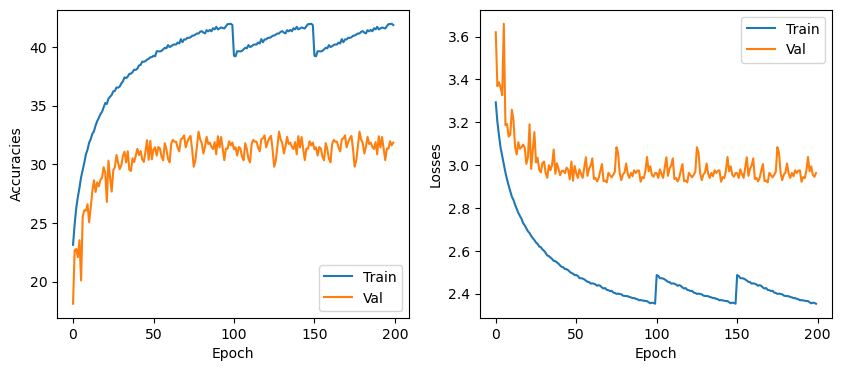

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(overall_train_accuracies, label='Train')
ax[0].plot(overall_val_accuracies, label='Val')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracies')
ax[0].legend()

ax[1].plot(overall_train_losses, label='Train')
ax[1].plot(overall_val_losses, label='Val')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Losses')
ax[1].legend()

#### Results

In [77]:
def result_top_1_and_top_5(model, data_loader, DEVICE):
    model.eval()
    model.to(DEVICE)

    running_loss = 0
    correct_predictions = 0
    top5_correct_predictions = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in tqdm(data_loader, desc="Validation"):
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            outputs = model(images)

            loss = F.cross_entropy(outputs, labels)

            running_loss += loss.item()
            
            _, predicted = torch.max(outputs.data, dim=1)
            
            total_samples += labels.size(0)
            
            correct_predictions += (predicted == labels).sum().item()
            
            _, predicted = torch.topk(outputs.data, k = 5, dim=1)

            top5_correct_predictions += (predicted == labels.unsqueeze(1)).sum().item()
            
        avg_loss = running_loss / len(data_loader)

        accuracy = 100 * correct_predictions/ total_samples
        top5_accuracy = (100 * top5_correct_predictions)/ total_samples

    return avg_loss, accuracy, top5_accuracy

In [78]:
val_loss, val_accuracy, val_top5_accuracy = result_top_1_and_top_5(model, val_loader, DEVICE)

Validation: 100%|██████████| 79/79 [00:01<00:00, 40.05it/s]


In [81]:
train_loss, train_accuracy, train_top5_accuracy = result_top_1_and_top_5(model, train_loader, DEVICE)

Validation: 100%|██████████| 782/782 [00:23<00:00, 33.56it/s]


In [82]:
val_accuracy, val_top5_accuracy, train_accuracy, train_top5_accuracy

(33.75, 61.51, 47.325, 75.084)

In [84]:
from IPython.display import Markdown, display

display(Markdown(f"""
| Dataset | Loss | Top-1 Accuracy | Top-5 Accuracy|
|--------|-------|----------------|---------------|
| Training Data | {train_loss:.4f} | {train_accuracy:.2f} | {train_top5_accuracy:.2f} |
| Validation Data | {val_loss:.4f} | {val_accuracy:.2f} | {val_top5_accuracy:.2f} |
"""))


| Dataset | Loss | Top-1 Accuracy | Top-5 Accuracy|
|--------|-------|----------------|---------------|
| Training Data | 2.1394 | 47.33 | 75.08 |
| Validation Data | 2.8287 | 33.75 | 61.51 |


In [85]:
torch.save(model.state_dict(), "tiny_imagenet_final_weights.pth")